# Configuración básica

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from abstractions.base import Function
from abstractions.functions import Variable, sin, cos, exp, ln

In [27]:
x = Variable()

# Implementación de métodos

In [28]:
# Implementar para hallar raíces de las derivadas, no de f

def biseccion(f: Function, a: float, b: float, tol: float = 1e-6, max_iter: int = 1000):
    
    df = f.derivative()

    fa = df.eval(a)
    fb = df.eval(b)

    if fa * fb > 0:
        raise ValueError(
            "La derivada no cambia de signo en el intervalo"
        )
    
    history = []

    for step in range(max_iter):

        xn = (a + b) / 2

        history.append(xn)

        fxn = df.eval(xn)

        if abs(fxn) < tol:
            return xn, step + 1, history

        if fa * fxn < 0:
            b = xn
            fb = fxn
        else:
            a = xn
            fa = fxn

    return xn, max_iter, history

def newton(f: Function, x0: float, tol: float = 1e-6, max_iter: int = 1000):
    
    df = f.derivative()
    ddf = df.derivative()

    xn = x0
    
    history = [xn]

    for step in range(max_iter):

        g = df.eval(xn)
        dg = ddf.eval(xn)

        if abs(g) < tol:
            return xn, step, history

        if abs(dg) < 1e-12:
            raise ValueError(
                "Segunda derivada cercana a cero"
            )

        xn_new = xn - g / dg
        
        history.append(xn_new)

        if abs(xn_new - xn) < tol:
            return xn_new, step + 1, history

        xn = xn_new

    return xn, max_iter, history

def descenso_gradiente(f: Function, x0: float, lr: float, tol: float = 1e-6, max_iter: int = 1000):
    
    df = f.derivative()

    xn = x0
    
    history = [xn]

    for step in range(max_iter):

        grad = df.eval(xn)

        if abs(grad) < tol:
            return xn, step, history

        xn_new = xn - lr * grad
        
        history.append(xn_new)

        if abs(xn_new - xn) < tol:
            return xn_new, step + 1, history

        xn = xn_new

    return xn, max_iter, history
    

### Prueba de métodos

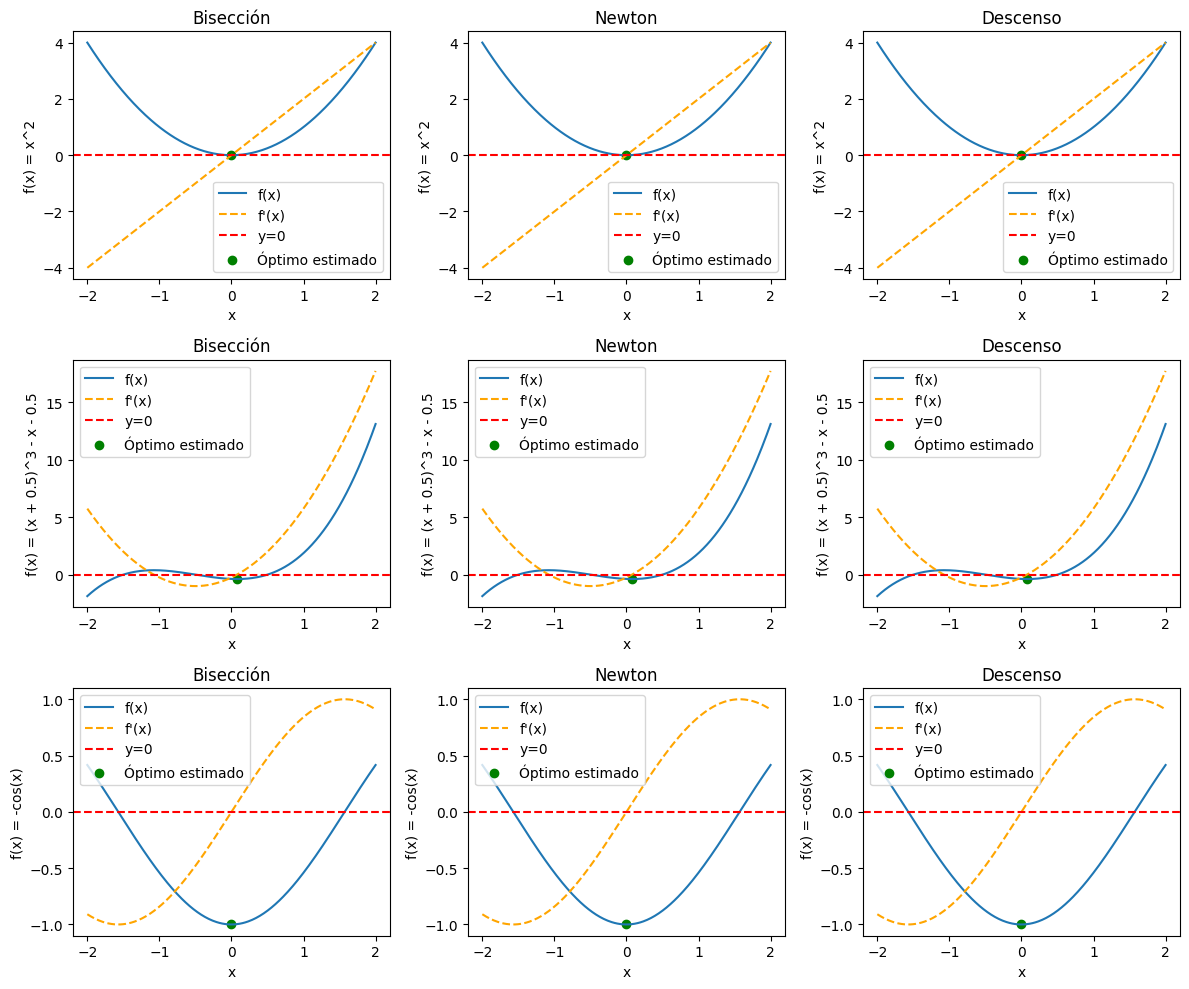

In [29]:
f1 = x**2
f2 = (x + 0.5)**3 - x - 0.5
f3 = -cos(x)

functions = [f1, f2, f3]

methods = [biseccion, newton, descenso_gradiente]
# Recomendación: exploren parámetros en esta etapa para ver distintos comportamientos.
parameters = [{"a":-1, "b":1}, {"x0": 1}, {"x0": 1, "lr": 1e-2}]

y_labels = ["f(x) = x^2", "f(x) = (x + 0.5)^3 - x - 0.5", "f(x) = -cos(x)"]
titles = ["Bisección", "Newton", "Descenso"]

lp = np.linspace(-2, 2, 300)

fig, axes = plt.subplots(3, 3, figsize=(12, 10))

for i, f in enumerate(functions):
    for j, m in enumerate(methods):
        ax = axes[i, j]
        # labels ejes
        ax.set_xlabel("x")
        ax.set_ylabel(y_labels[i])

        # métodos
        method = methods[j]
        params = parameters[j] 
        res, step, _ = method(f, **params)

        # graficas
        ax.plot(lp, np.array(list(map(lambda v: f.eval(v), lp))))
        ax.plot(lp, np.array(list(map(lambda v: f.derivative().eval(v), lp))), linestyle="--", color="orange")
        ax.axhline(0, linestyle="--", color="red")
        ax.scatter(res, f.eval(res), color="green")

        ax.plot()
        ax.legend([f"f(x)", "f'(x)", "y=0", "Óptimo estimado"])
        ax.set_title(titles[j])

plt.tight_layout()
plt.show()

# Aplicación a función no trivial

In [30]:
f = x**2 + 2*sin(3*x)

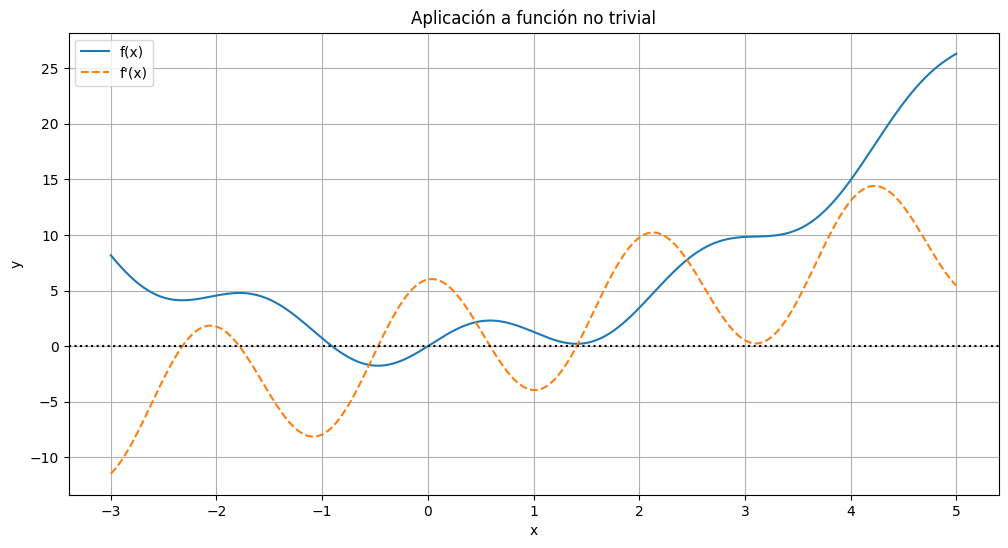

In [42]:
df = f.derivative()

f_values = [f.eval(v) for v in lp]
df_values = [df.eval(v) for v in lp]

plt.figure(figsize=(12,6))

plt.plot(
    lp,
    f_values,
    label="f(x)"
)

plt.plot(
    lp,
    df_values,
    "--",
    label="f'(x)"
)

plt.axhline(
    0,
    color="black",
    linestyle=":"
)

plt.title("Aplicación a función no trivial")
plt.xlabel("x")
plt.ylabel("y")

plt.legend()

plt.grid(True)
plt.show()

In [32]:
# Evaluación de métodos y generación de tablas
experimentos = []

# bisección
for a, b in [(-2, 1), (-1, 0), (1, 2)]:
    try:
        r, it, _ = biseccion(f, a, b)

        experimentos.append(
            {
                "Metodo": "Biseccion",
                "Inicial": f"[{a},{b}]",
                "Resultado": r,
                "f(x)": f.eval(r),
                "Iteraciones": it,
            }
        )
    except Exception as e:
        experimentos.append(
            {
                "Metodo": "Biseccion",
                "Inicial": f"[{a},{b}]",
                "Resultado": str(e),
                "f(x)": None,
                "Iteraciones": None,
            }
        )

# newton
for x0 in [-2, -1, 4]:

    r, it, _ = newton(f, x0)

    experimentos.append(
        {
            "Metodo": "Newton",
            "Inicial": x0,
            "Resultado": r,
            "f(x)": f.eval(r),
            "Iteraciones": it,
        }
    )

# descenso
for x0 in [-3, 0.585, 4]:

    r, it, _ = descenso_gradiente(
        f,
        x0=x0,
        lr=0.01
    )

    experimentos.append(
        {
            "Metodo": "Gradiente",
            "Inicial": x0,
            "Resultado": r,
            "f(x)": f.eval(r),
            "Iteraciones": it,
        }
    )

pd.DataFrame(experimentos)

,Metodo,Inicial,Resultado,f(x),Iteraciones
0,Biseccion,"[-2,1]",-1.782932,4.787319,23
1,Biseccion,"[-1,0]",-0.471043,-1.753311,24
2,Biseccion,"[1,2]",1.407957,0.216284,21
3,Newton,-2,-1.782932,4.787319,5
4,Newton,-1,0.589531,2.308551,4
5,Newton,4,7.820892,59.176196,1000
6,Gradiente,-3,-2.322813,4.129721,77
7,Gradiente,0.585,-0.471039,-1.753311,89
8,Gradiente,4,1.407961,0.216284,180


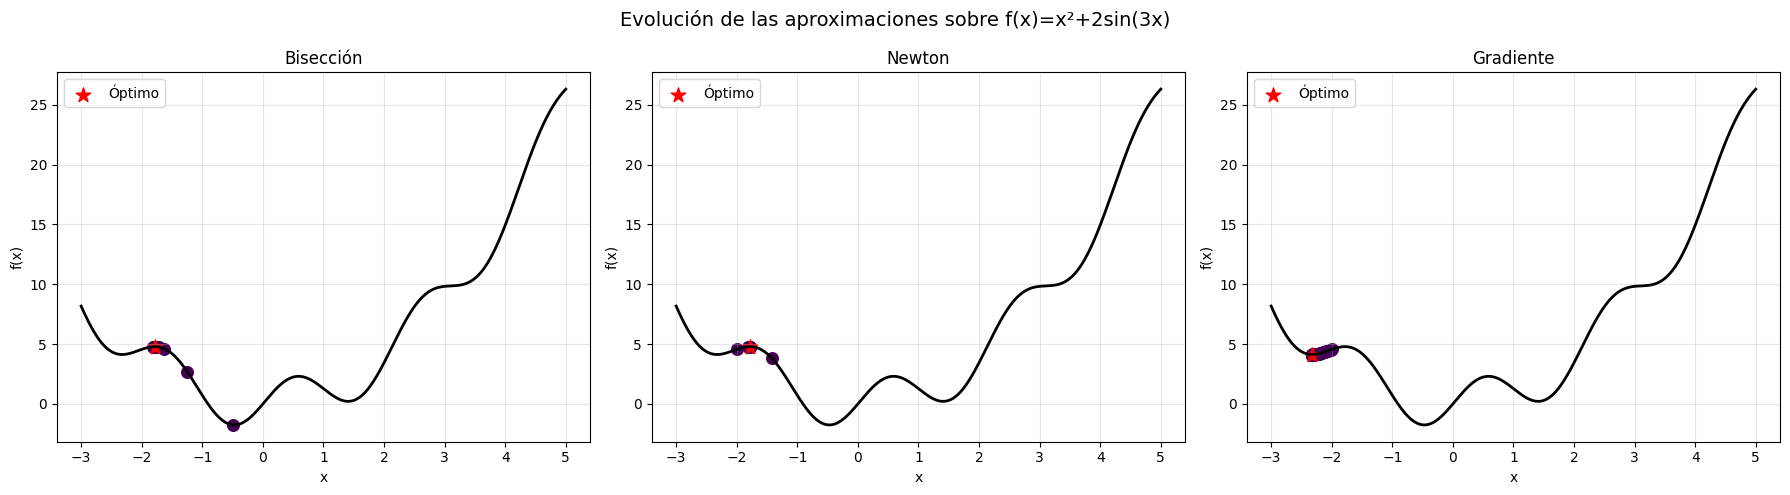

In [43]:
# BONUS: visualización de la evolución de los métodos

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metodos = [
    (
        "Bisección",
        biseccion,
        {"a": -2, "b": 1}
    ),
    (
        "Newton",
        newton,
        {"x0": -2}
    ),
    (
        "Gradiente",
        descenso_gradiente,
        {
            "x0": -2,
            "lr": 0.01
        }
    )
]

for ax, (nombre, metodo, params) in zip(axes, metodos):

    resultado, iteraciones, history = metodo(
        f,
        **params
    )

    # curva de la función
    ax.plot(
        lp,
        [f.eval(v) for v in lp],
        color="black",
        linewidth=2
    )

    # puntos de la trayectoria
    for i, xk in enumerate(history):

        ax.scatter(
            xk,
            f.eval(xk),
            c=[i],
            cmap="viridis",
            s=70
        )

    # punto final
    ax.scatter(
        resultado,
        f.eval(resultado),
        color="red",
        s=120,
        marker="*",
        label="Óptimo"
    )

    ax.set_title(nombre)
    ax.set_xlabel("x")
    ax.set_ylabel("f(x)")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.suptitle(
    "Evolución de las aproximaciones sobre f(x)=x²+2sin(3x)",
    fontsize=14
)

plt.tight_layout()
plt.show()

# Ajuste de datos

In [33]:
df_linear = pd.read_csv("datasets/linear_model.csv")
df_exp = pd.read_csv("datasets/exp_model.csv")
df_sin = pd.read_csv("datasets/sin_model.csv")

w = Variable()

In [34]:
# Genere la función de pérdida

In [35]:
# Optimice la función de pérdida

In [36]:
# Grafique datos y ajuste

# BONUS: